# EfficientDet 차량 탐지: 정확도·속도·영상 열화 비교

입력 해상도와 검출 임계값을 바꾸면 차량 누락·오탐·처리 시간이 어떻게 달라지는지, 선택한 설정이 어두움·흐림에서도 유지되는지 비교했다.

- 실행: 2026-10-04, VS Code + Google Colab GPU(Tesla T4)
- 모델: COCO 사전학습 EfficientDet-D0, FP32, batch 1, 추가 학습 없음
- 데이터: 공개 Vehicle Detection Image Dataset, 검증·평가 각각 60장
- 실행 ID: `20261004T094456_281232Z`
- 선택 설정: 768/0.3, 원본 최종 평가 F1 0.6126, 중앙 처리 시간 62.91ms

공장 출입구·물류 구역 차량 모니터링을 응용 시나리오로 삼았다. 실제 실험은 도로 이미지의 승용차 박스를 평가하며, 분류 정확도 대신 Precision·Recall·F1·AP50을 사용한다.


## 1. 실행 방법과 시간 계획

VS Code에서 `Select Kernel → Colab`으로 GPU 런타임에 연결한 뒤 위에서 아래로 실행한다. 연결·데이터 확인 30분, 추론·조건 비교 45분, 해석·보고서 20분, 회고 15분, 저장·공개 확인 10분을 계획했다. 실행 로그의 128.26초는 실험 객체 생성부터 보고서 생성까지의 구간이며 전체 준비 시간을 뜻하지 않는다.

아래 셀은 작은 코드 스냅샷을 풀어 Colab 서버에 실행 파일을 준비한다. 저장소에서는 `src/`, `configs/`, `tests/`, `docs/`로 나누어 관리한다. 로컬 D 드라이브와 서버의 `/content/...`는 서로 다른 경로다.

저장된 측정 출력은 2026-10-04 실행 결과다. 이후 문서와 포함 소스를 정리했으며, 재실행하면 새 실행 ID가 생성된다. 새 결과에 맞춰 해석도 갱신한다.


In [ ]:
import base64, hashlib, io, json, os, sys, zipfile
from pathlib import Path

# 원격 서버 경로입니다. Windows의 D: 경로와 별개입니다.
ROOT = Path("/content/efficientdet_vehicle_project") if os.name != "nt" else Path.cwd()
USE_UPLOADED_PROJECT = False  # 수정한 src/를 직접 업로드했다면 True
SOURCE_BUNDLE_SHA256 = "5e087b9c2d7c640ef1fe453a3f9387d5835a54d0294eb98e16ddc4162c5eec04"
SOURCE_BUNDLE_BASE64 = "..."

ROOT = ROOT.resolve()
ROOT.mkdir(parents=True, exist_ok=True)
if not USE_UPLOADED_PROJECT:
    raw = base64.b64decode(SOURCE_BUNDLE_BASE64)
    assert hashlib.sha256(raw).hexdigest() == SOURCE_BUNDLE_SHA256
    with zipfile.ZipFile(io.BytesIO(raw)) as archive:
        # Existing edited files are never silently overwritten.
        for member in archive.infolist():
            target = (ROOT / member.filename).resolve()
            if not target.is_relative_to(ROOT):
                raise ValueError("Invalid source archive path")
            if target.exists() and target.read_bytes() != archive.read(member):
                raise RuntimeError(f"Source snapshot differs: {target}. Use a fresh ROOT or USE_UPLOADED_PROJECT=True.")
        for member in archive.infolist():
            target = ROOT / member.filename
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(archive.read(member))
if not (ROOT / "src/vehicle_project/experiment.py").is_file():
    raise FileNotFoundError("프로젝트 src/ 파일을 확인하세요.")
os.chdir(ROOT)
print("실행 폴더:", ROOT)
print("소스 스냅샷:", SOURCE_BUNDLE_SHA256)


In [2]:
import subprocess
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU가 없습니다. VS Code에서 Colab GPU 커널을 선택한 뒤 실행하세요.")
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
# Colab 기본 torch/torchvision은 교체하지 않습니다.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT/"requirements.txt")], check=True)
sys.path.insert(0, str(ROOT/"src"))
from vehicle_project.common import read_json, write_json
from vehicle_project.experiment import Experiment
import pandas as pd
from IPython.display import display, Markdown, Image as DisplayImage


GPU: Tesla T4
PyTorch: 2.11.0+cu130


## 2. 목표·가설과 조건 고정

차량 관련 주제를 다루면서 해상도·임계값 조정만으로 누락을 얼마나 줄일 수 있는지 살펴봤다. 선택 지표는 오탐과 누락의 균형을 나타내는 F1이며, 차량을 놓치는 문제를 파악하기 위해 Recall과 작은 차량 Recall을 함께 기록했다.

검증할 가설은 높은 해상도가 작은 차량 탐지에 유리하지만 처리 시간이 늘 수 있다는 것이다. 낮은 confidence는 누락을 줄이는 대신 오탐을 늘릴 수 있다. 어두움·흐림은 같은 이미지에 각각 적용해 비교한다. 설정은 원본 검증 결과로 선택하고 최종 평가에서는 고정한다.


In [3]:
CONFIG = read_json(ROOT/"configs/experiment.json")

QUICK_MODE = False  # 처음부터 30장씩 평가하려면 True. 실행 중 바꾸지 않기.
if QUICK_MODE:
    CONFIG.update(validation_images=30, test_images=30)

# 이미 데이터를 서버에 올렸다면 아래 두 경로를 수정합니다.
# CONFIG["dataset_root"] = "/content/vehicle_dataset"
# CONFIG["annotation_root"] = "/content/vehicle_dataset/No_Apply_Grayscale/.../Vehicles_Detection.v8i.coco"
# 클래스 이름이 다르면 실제 categories를 확인한 뒤 수정합니다.
# CONFIG["target_category_names"] = ["Car"]

print(json.dumps(CONFIG, ensure_ascii=False, indent=2))


{
  "seed": 42,
  "dataset_handle": "pkdarabi/vehicle-detection-image-dataset",
  "dataset_root": null,
  "dataset_variant": "No_Apply_Grayscale",
  "annotation_root": null,
  "target_category_names": [
    "Car"
  ],
  "validation_images": 60,
  "test_images": 60,
  "frame_gap": 30,
  "sizes": [
    512,
    768
  ],
  "thresholds": [
    0.1,
    0.3,
    0.5
  ],
  "baseline": {
    "size": 512,
    "threshold": 0.3
  },
  "nms_iou": 0.5,
  "match_iou": 0.5,
  "ap_score_floor": 0.001,
  "max_detections": 100,
  "verify_coco_ap": true,
  "warmup": 5,
  "timing_images": 10,
  "timing_repeats": 3,
  "conditions": [
    "original",
    "dark",
    "blur"
  ],
  "dark_factor": 0.6,
  "blur_kernel": 5,
  "blur_sigma": 1.0,
  "require_cuda": true,
  "upstream_ref": "master",
  "experiment_budget_minutes": 55
}


## 3. 데이터 준비와 누수 점검

Kaggle 공개 차량 데이터의 컬러 COCO 버전(`No_Apply_Grayscale`, 데이터 버전 7)을 사용했다. 승용차 `Car`만 평가하고 Truck·Pickup·Motorcycle·Bus는 합치지 않았다.

같은 원본의 변형본과 픽셀 중복을 검사했다. 파일명 프레임 번호를 기준으로 앞 시간 구간은 검증, 뒤 구간은 최종 평가로 나누고 경계에 30프레임 간격을 뒀다. 분할·주석·이미지 해시는 결과 폴더에 저장했다. 이 분할만으로 서로 다른 카메라의 평가가 보장되지는 않는다.


In [4]:
exp = Experiment(ROOT, CONFIG)
audit = exp.prepare_data()
display(pd.DataFrame(audit["category_annotation_counts_before_dedup"].items(), columns=["원본 클래스", "주석 수"]))
print(json.dumps(audit["split"], ensure_ascii=False, indent=2))
print("중복 제거:", audit["duplicates_removed"])
print("실제 결과 저장 위치:", exp.output)


공개 차량 데이터 다운로드 중입니다. 인증이 필요하면 오류 안내에 따라 직접 로그인하세요.


100%|██████████| 262M/262M [00:02<00:00, 135MB/s]  

Extracting files...


검증 60장 / 최종 평가 60장 / 대상 ['Car']


,원본 클래스,주석 수
0,Truck,58
1,Car,2104
2,Pickup,278
3,Motorcycle,411
4,Bus,35


{
  "name": "blocked_temporal",
  "pivot_frame": 3240,
  "gap_frames": 30,
  "limitation": "Temporal separation is not an independent camera/scene split. Frame numbers are inferred from names; verify the displayed samples.",
  "validation_pool": 71,
  "test_pool": 71,
  "validation_images": 60,
  "test_images": 60,
  "unused_images": 23,
  "original_dataset_splits_reassigned": true,
  "reason": "No new model training. Validation/test are rebuilt to reduce adjacent-frame leakage."
}
중복 제거: 0
실제 결과 저장 위치: /content/efficientdet_vehicle_project/results/20261004T094456_281232Z


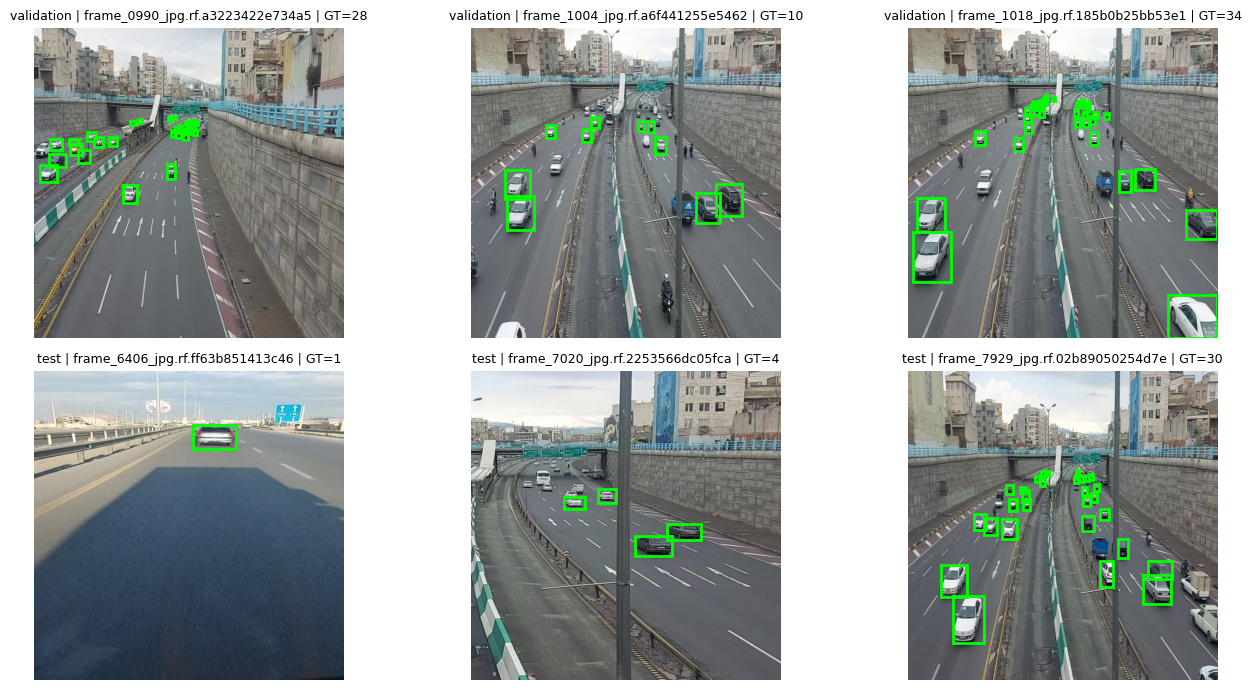

박스 상대 면적과 이미지별 객체 수


,split,images,car_boxes,images_without_car
0,validation,60,1106,1
1,test,60,706,9


In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from vehicle_project.inference import load_rgb

samples = exp.validation[:3] + exp.test_records[:3]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, record in zip(axes.flat, samples):
    ax.imshow(load_rgb(record))
    for x1,y1,x2,y2 in record["boxes"]:
        ax.add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor="lime",linewidth=2))
    split = "validation" if record in exp.validation else "test"
    ax.set_title(f"{split} | {record['filename'][:32]} | GT={len(record['boxes'])}",fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("박스 상대 면적과 이미지별 객체 수")
display(pd.DataFrame([{"split": name, "images": len(records), "car_boxes": sum(len(r["boxes"]) for r in records),
                       "images_without_car": sum(not r["boxes"] for r in records)}
                     for name,records in [("validation",exp.validation),("test",exp.test_records)]]))


### 데이터에서 확인한 특성

검증 60장에는 승용차 정답 1,106개, 최종 평가 60장에는 706개가 있다. 이미지 면적의 1% 이하인 작은 차량은 각각 1,051개(95.0%), 645개(91.4%)다. 이 데이터에서는 큰 차량 몇 대를 잘 찾는 것보다 멀리 있는 작은 차량의 누락을 줄이는 것이 중요하다고 판단했다. 전체 F1과 함께 작은 차량 Recall을 확인한 이유다.

원본 데이터는 고유 이미지 143장이고 중복 제거 수와 박스 좌표 보정 기록은 모두 0이다. 주석 오류가 전혀 없다는 뜻은 아니다. 시간 순서와 30프레임 경계 간격으로 검증·평가를 분리했지만, 도로 구도와 촬영 환경이 비슷해 서로 다른 카메라로 일반화되는지는 확인할 수 없다.


## 4. 평가 로직 검증과 모델 로드

아래 작은 테스트는 평가 계산과 데이터 분할의 동작만 검사합니다. 테스트용 예측 수치는 EfficientDet 성능이 아닙니다.

모델은 90개 COCO 슬롯을 가진 D0를 로드하고 `car` 슬롯 2를 사용합니다. 주석의 category ID와 모델 슬롯 번호는 서로 다릅니다. RGB 전처리 기준을 모든 조건에 일관되게 적용합니다.


In [6]:
test_env = dict(os.environ)
test_env["PYTHONPATH"] = str(ROOT/"src")
test_env["VEHICLE_TEST_SCRATCH"] = str(ROOT/".cache/test-fixtures")
completed = subprocess.run([sys.executable,"-m","unittest","discover","-s",str(ROOT/"tests"),"-v"],
                           cwd=ROOT,env=test_env,text=True,capture_output=True)
print(completed.stdout)
print(completed.stderr)
completed.check_returncode()
model_info = exp.load_model()
print(json.dumps(model_info, ensure_ascii=False, indent=2))


validation / original / 768: 1/1
validation / original / 512: 1/1
test / original / 512: 1/1
test / dark / 512: 1/1

test_coco_load_and_temporal_gap (test_data.DataTests.test_coco_load_and_temporal_gap) ... ok
test_derived_names_share_origin (test_data.DataTests.test_derived_names_share_origin) ... ok
test_exact_duplicates_removed (test_data.DataTests.test_exact_duplicates_removed) ... ok
test_stage_order_selection_and_export (test_experiment.ExperimentTests.test_stage_order_selection_and_export) ... ok
test_ap_penalizes_early_false_positives (test_metrics.BoxMetricsTests.test_ap_penalizes_early_false_positives) ... ok
test_duplicate_predictions_are_false_positives (test_metrics.BoxMetricsTests.test_duplicate_predictions_are_false_positives) ... ok
test_empty_split_fails (test_metrics.BoxMetricsTests.test_empty_split_fails) ... ok
test_iou_and_empty_shapes (test_metrics.BoxMetricsTests.test_iou_and_empty_shapes) ... ok
test_match_uses_best_unmatched_box (test_metrics.BoxMetricsTests.te

## 5. 원본 검증 데이터: 해상도 × 임계값 6조건

원본 검증 이미지에서만 설정을 선택합니다. AP50용 예측은 낮은 공통 score cutoff로 저장하고, 각 운영 임계값에서 속도를 다시 측정합니다. CUDA 준비 실행과 동기화를 포함하며, 파일 읽기와 그림 그리기는 타이머 밖에 둡니다.

**선택 규칙:** F1 최대 → 정확히 같으면 중앙 처리 시간 최소. 이 규칙은 최종 평가 전에 고정되어 있습니다.


In [7]:
validation_rows, selection = exp.run_validation()
columns = ["size","threshold","precision","recall","f1","ap50","pipeline_median_ms","pipeline_p95_ms","count_mae"]
display(pd.DataFrame(validation_rows)[columns].round(4))
print("최종 평가 전 고정된 설정:", selection)


validation / original / 768: 1/60
validation / original / 768: 20/60
validation / original / 768: 40/60
validation / original / 768: 60/60
validation / original / 512: 1/60
validation / original / 512: 20/60
validation / original / 512: 40/60
validation / original / 512: 60/60


,size,threshold,precision,recall,f1,ap50,pipeline_median_ms,pipeline_p95_ms,count_mae
0,512,0.1,0.1755,0.5651,0.2678,0.3838,53.6988,61.1012,40.9333
1,512,0.3,0.7361,0.2523,0.3758,0.3838,53.7917,63.9786,12.5833
2,512,0.5,0.9251,0.1564,0.2676,0.3838,70.1891,89.6552,15.3833
3,768,0.1,0.1796,0.7387,0.2889,0.5369,63.5684,74.8378,57.4000
4,768,0.3,0.7591,0.3960,0.5205,0.5369,68.3026,93.0148,10.0500
5,768,0.5,0.8976,0.2694,0.4145,0.5369,64.9219,96.9035,13.2000


최종 평가 전 고정된 설정: {'size': 768, 'threshold': 0.3, 'validation_f1': 0.5204991087344029, 'rule': 'maximum validation F1; exact tie: lowest median memory-pipeline latency', 'frozen_utc': '2026-10-04T09:46:10.614954+00:00'}


### 검증 결과 해석과 설정 선택

검증 F1이 가장 높은 조건은 768/0.3으로 0.5205였다. 512/0.3의 0.3758보다 높아 768/0.3을 최종 평가 전에 고정했다. 모델은 두 조건 모두 동일한 EfficientDet-D0이며, 입력 크기만 달라졌다.

768에서 임계값을 0.1로 낮추면 Recall은 0.7387까지 올라가지만 FP가 3,733개로 늘고 Precision은 0.1796으로 떨어진다. 반대로 0.5에서는 Precision이 0.8976인 대신 Recall이 0.2694로 낮아진다. 단순히 누락만 줄이기 위해 임계값을 낮추기보다 오탐과 누락의 균형을 잡는 0.3이 이 데이터에 적합하다고 판단했다.

같은 해상도의 AP50이 동일한 것은 공통 score floor 0.001로 평가하기 때문이다. 임계값의 효과는 Precision·Recall·F1로 비교했다. 검증 속도는 512/0.5에서 70.19ms로 일부 768 조건보다 느린 값도 나왔으므로, 한 번의 측정 순서만으로 속도의 일정한 경향을 단정하기 어렵다.


## 6. 최종 평가와 영상 열화

기본(512/0.3)과 선택 설정을 고정한 채 별도 평가 이미지에서 비교합니다. 원본·밝기 0.6배·Gaussian blur를 같은 이미지에 적용합니다. 이미지 수를 세 배의 독립 표본처럼 해석하지 않습니다.

기본과 선택 설정이 같으면 두 행의 결과도 같습니다. 최종 평가를 보고 설정을 다시 고르지 않습니다.


In [8]:
test_rows = exp.run_test()
test_columns = ["policy","condition","size","threshold","precision","recall","f1","ap50","coco_ap50_check","pipeline_median_ms","count_mae","small_gt","small_recall"]
display(pd.DataFrame(test_rows)[test_columns].round(4))


test / original / 512: 1/60
test / original / 512: 20/60
test / original / 512: 40/60
test / original / 512: 60/60
test / original / 768: 1/60
test / original / 768: 20/60
test / original / 768: 40/60
test / original / 768: 60/60
test / dark / 512: 1/60
test / dark / 512: 20/60
test / dark / 512: 40/60
test / dark / 512: 60/60
test / dark / 768: 1/60
test / dark / 768: 20/60
test / dark / 768: 40/60
test / dark / 768: 60/60
test / blur / 512: 1/60
test / blur / 512: 20/60
test / blur / 512: 40/60
test / blur / 512: 60/60
test / blur / 768: 1/60
test / blur / 768: 20/60
test / blur / 768: 40/60
test / blur / 768: 60/60


,policy,condition,size,threshold,precision,recall,f1,ap50,coco_ap50_check,pipeline_median_ms,count_mae,small_gt,small_recall
0,baseline,original,512,0.3,0.7350,0.3654,0.4882,0.4641,0.4641,54.3262,7.4500,645,0.3054
1,selected,original,768,0.3,0.7159,0.5354,0.6126,0.5937,0.5937,62.9097,6.2000,645,0.4930
2,baseline,dark,512,0.3,0.7547,0.3442,0.4728,0.4652,0.4652,67.8298,7.7000,645,0.2853
3,selected,dark,768,0.3,0.7460,0.5241,0.6156,0.5995,0.5995,63.4830,6.4000,645,0.4806
4,baseline,blur,512,0.3,0.7645,0.3357,0.4665,0.4562,0.4562,52.9113,7.7333,645,0.2729
5,selected,blur,768,0.3,0.7386,0.4802,0.5820,0.5793,0.5793,61.9028,6.4833,645,0.4326


## 7. 그래프와 실패 사례

검증 정확도·속도 그래프와 최종 평가 열화 비교를 함께 살펴본다. 예시 이미지는 선택 설정의 원본 결과에서 FP+FN이 큰 두 장과 작은 한 장이다. 누락이 많은 장면과 탐지가 된 장면을 나란히 확인한다.


# EfficientDet 차량 탐지 실험 결과

2026-10-04 Colab Tesla T4에서 측정한 결과와 해석을 정리했다. 검증 60장으로 설정을 선택하고 별도 평가 60장에서 원본·어두움·흐림을 비교했다.

- 검증 60장 / 최종 평가 60장
- 검증으로 선택한 설정: 입력 768, confidence 0.3
- 원본 최종 평가 F1: 기본 0.4882 → 선택 0.6126 (차이 +0.1245)
- 기본/선택 처리 시간 비율: 0.864배. 1보다 크면 선택 설정이 이 측정에서 더 빠릅니다.
- 개선되지 않은 결과도 그대로 보고합니다. 설정 선택에는 최종 평가를 사용하지 않았습니다.

## 검증 결과

| size | threshold | precision | recall | f1 | ap50 | pipeline_median_ms | pipeline_p95_ms | count_mae |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 512 | 0.1000 | 0.1755 | 0.5651 | 0.2678 | 0.3838 | 53.6988 | 61.1012 | 40.9333 |
| 512 | 0.3000 | 0.7361 | 0.2523 | 0.3758 | 0.3838 | 53.7917 | 63.9786 | 12.5833 |
| 512 | 0.5000 | 0.9251 | 0.1564 | 0.2676 | 0.3838 | 70.1891 | 89.6552 | 15.3833 |
| 768 | 0.1000 | 0.1796 | 0.7387 | 0.2889 | 0.5369 | 63.5684 | 74.8378 | 57.4000 |
| 768 | 0.3000 | 0.7591 | 0.3960 | 0.5205 | 0.5369 | 68.3026 | 93.0148 | 10.0500 |
| 768 | 0.5000 | 0.8976 | 0.2694 | 0.4145 | 0.5369 | 64.9219 | 96.9035 | 13.2000 |

AP50은 낮은 공통 score cutoff에서 계산하므로 같은 해상도의 임계값 행에서 동일합니다. 임계값 최적화 효과는 F1·Precision·Recall로 비교합니다.

## 최종 평가

| policy | condition | size | threshold | precision | recall | f1 | ap50 | coco_ap50_check | pipeline_median_ms | count_mae | small_gt | small_recall |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| baseline | original | 512 | 0.3000 | 0.7350 | 0.3654 | 0.4882 | 0.4641 | 0.4641 | 54.3262 | 7.4500 | 645 | 0.3054 |
| selected | original | 768 | 0.3000 | 0.7159 | 0.5354 | 0.6126 | 0.5937 | 0.5937 | 62.9097 | 6.2000 | 645 | 0.4930 |
| baseline | dark | 512 | 0.3000 | 0.7547 | 0.3442 | 0.4728 | 0.4652 | 0.4652 | 67.8298 | 7.7000 | 645 | 0.2853 |
| selected | dark | 768 | 0.3000 | 0.7460 | 0.5241 | 0.6156 | 0.5995 | 0.5995 | 63.4830 | 6.4000 | 645 | 0.4806 |
| baseline | blur | 512 | 0.3000 | 0.7645 | 0.3357 | 0.4665 | 0.4562 | 0.4562 | 52.9113 | 7.7333 | 645 | 0.2729 |
| selected | blur | 768 | 0.3000 | 0.7386 | 0.4802 | 0.5820 | 0.5793 | 0.5793 | 61.9028 | 6.4833 | 645 | 0.4326 |

## 영상 열화에 대한 관찰

- dark: 원본 대비 F1 차이 +0.0030, Recall 차이 -0.0113. 같은 이미지의 변형본을 짝 비교했습니다.
- blur: 원본 대비 F1 차이 -0.0307, Recall 차이 -0.0552. 같은 이미지의 변형본을 짝 비교했습니다.

## 측정 방법과 해석 범위

- 모델: COCO 사전학습 EfficientDet-D0, FP32, batch 1. 추가 학습 없음. 정확도 평가는 car 단일 클래스.
- AP score floor=0.001, NMS IoU=0.5, 정답 대응 IoU=0.5, max detections=100.
- 단일 클래스 AP50을 계산하고 pycocotools와 대조합니다. AP@[.5:.95]로 표기하지 않습니다.
- 속도: GPU 준비 실행 후 전처리·CPU→GPU 전송·추론·NMS·원본 좌표 복원·CPU 결과 변환을 포함합니다. CUDA 동기화를 사용합니다.
- 디스크 읽기·합성 열화 생성·그림 그리기·영상 디코딩은 속도 측정에서 제외합니다. memory_pipeline_fps는 실서비스 영상 FPS가 아닙니다.
- 상대 면적 1% 이하를 작은 차량으로 정의한 보조 Recall을 표시합니다. COCO의 small 정의와 다릅니다. 분모가 없으면 N/A입니다.
- 합성 어두움·Gaussian blur는 실제 야간·우천·주행 모션블러와 다릅니다. 공장 출입구 적용을 가정한 공개 차량 데이터 예비 실험입니다.
- 분할 한계: 파일명에서 추출한 프레임 번호로 시간 구간을 나눴다. 카메라·촬영 장소의 독립성은 보장되지 않는다.
- 표본 수가 작고 동일 카메라 장면일 수 있습니다. 일반화 또는 통계적 유의성을 주장하지 않습니다.

## 그림



## 결과 해석

원본 최종 평가에서 768/0.3은 기본 512/0.3보다 F1이 0.4882에서 0.6126으로 12.45%p, Recall이 0.3654에서 0.5354로 17.00%p 높았다. AP50은 0.4641에서 0.5937로, 작은 차량 Recall은 0.3054에서 0.4930으로 개선됐다. 프레임별 차량 수 MAE도 7.45대에서 6.20대로 줄었다.

대신 중앙 처리 시간은 54.33ms에서 62.91ms로 약 15.8% 늘었다. 차량 누락을 줄이는 목적에서는 이 비용을 감수하고 768/0.3을 선택할 만하다. 다만 선택 설정에서도 정답 706대 중 328대를 놓쳤으므로 실제 출입 관리에 바로 적용하기에는 부족하다. 영상 디코딩을 제외한 속도이므로 실제 CCTV 처리율은 별도 측정해야 한다.

밝기를 0.6배로 낮추면 선택 설정의 F1이 0.6126에서 0.6156으로 소폭 높아졌지만, Recall은 0.5354에서 0.5241로 낮아졌다. TP가 378개에서 370개로 줄면서 FP도 150개에서 126개로 줄어든 결과다. 어두운 영상이 더 좋다는 결론보다, 누락과 오탐을 함께 봐야 한다는 점을 확인했다.

흐림에서는 F1이 0.5820, Recall이 0.4802로 낮아졌고 작은 차량 Recall도 0.4326으로 떨어졌다. 작은 차량의 경계·세부 정보 손실이 원인일 수 있으나, 크기와 가림을 분리한 추가 실험으로 확인해야 한다.

## 실패 사례

| 예시 / 이미지 ID | 원본 결과 | 열화 비교와 해석 |
| --- | --- | --- |
| example_1 / `910a8e9853b53b3e` | 정답 38, TP 12, FP 3, FN 26 | 화면 먼 쪽의 작은 차량이 밀집한 장면이다. 어두움과 흐림에서도 FN 26으로, 원본부터 많은 차량을 놓치는 문제가 크다. |
| example_2 / `6b512c4afc6cb9a8` | 정답 35, TP 13, FP 4, FN 22 | 흐림에서 TP 11, FN 24로 악화됐다. 작은 차량이 많은 장면에서 흐림의 추가 누락을 확인할 수 있다. |
| example_3 / `e69d73377914c3a2` | 정답 1, TP 1, FP 0, FN 0 | 상대적으로 가까운 차량 한 대는 세 조건에서 모두 탐지했다. 이 장면만으로 전체 성능을 설명할 수는 없다. |

실패가 큰 두 장과 오류가 작은 한 장을 함께 살펴봤다. 이 세 장은 전체 데이터의 대표성을 보장하는 무작위 표본이 아니다. 밀집·거리·가림이 동시에 달라지므로 각각의 영향은 아직 분리하지 못했다.




## KPT와 다음 행동

**Keep**

검증 데이터에서 설정을 고른 뒤 최종 평가에 고정한 방법을 유지하고 싶다. 동일 이미지에 원본·어두움·흐림을 적용해 비교하고, F1뿐 아니라 Recall·작은 차량 Recall·처리 시간을 함께 기록한 것도 유지할 점이다. 표와 실패 이미지가 함께 있어 평균 수치 뒤에 남은 누락을 확인하기 쉬웠다.

**Problem**

선택 설정의 원본 Recall이 0.5354에 머물렀고 작은 차량 Recall도 0.4930이었다. example_1에서는 38대 중 26대를 놓쳤다. 표본은 검증·평가 각각 60장이고 같은 카메라의 장면일 가능성이 남아 있다. 합성 어두움·흐림만으로 실제 야간·우천 환경을 판단할 수 없고, 속도는 세션을 바꿔 반복 확인하지 못했다.

**Try**

다음 실험에서는 이미 고정한 최종 평가 설정을 유지하면서 차량 크기별 누락과 합성 열화 강도별 변화를 분리해 살펴보고 싶다. 새 입력 크기나 다른 모델의 선택이 필요하면 검증 데이터에서 결정하고, 추가로 확보한 별도 장면에서 확인하겠다.

**Action - 무엇을**

① 같은 Tesla T4에서 512/0.3과 768/0.3의 속도를 순서를 바꿔 3라운드 측정한다. ② 선택 설정을 고정하고 검증 60장에 밝기 1.0/0.8/0.6/0.4, blur sigma 0/0.5/1.0/1.5(커널 5×5)를 각각 적용한다. ③ 다른 촬영 장소의 공개 차량 이미지 30장 이상과 승용차 박스를 확보해 별도 평가한다.

**Action - 언제**

다음 실습 첫 30분에는 속도 반복 측정을, 이어지는 30분에는 열화 강도 비교를 진행한다. 그 다음 실습에서 다른 촬영 장소의 데이터와 주석을 확인한 뒤 고정 설정을 평가한다.

**Action - 완료 기준**

① 두 설정 × 3라운드의 원시 처리 시간과 중앙값·p95 표를 저장한다. ② 조건별 F1·Recall·작은 차량 Recall 표와 강도별 그래프를 저장한다. ③ 새 이미지 30장 이상의 출처·분할·주석 점검 기록과 평가 표를 남긴다. 순서별 속도 차이가 크면 속도 순위를 보류하고, 새 장면에서 Recall 하락이 크면 데이터 추가와 미세 조정을 다음 과제로 정한다.

[실험 해석과 KPT 전체](PERSONAL_REFLECTION.md)

## 재현 자료

`config.json`, `data_audit.json`, `split_manifest.json`, `model_provenance.json`, `environment.json`, `selection.json`, `timings/`를 함께 보존합니다.

데이터 출처: https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset
모델 출처: https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch


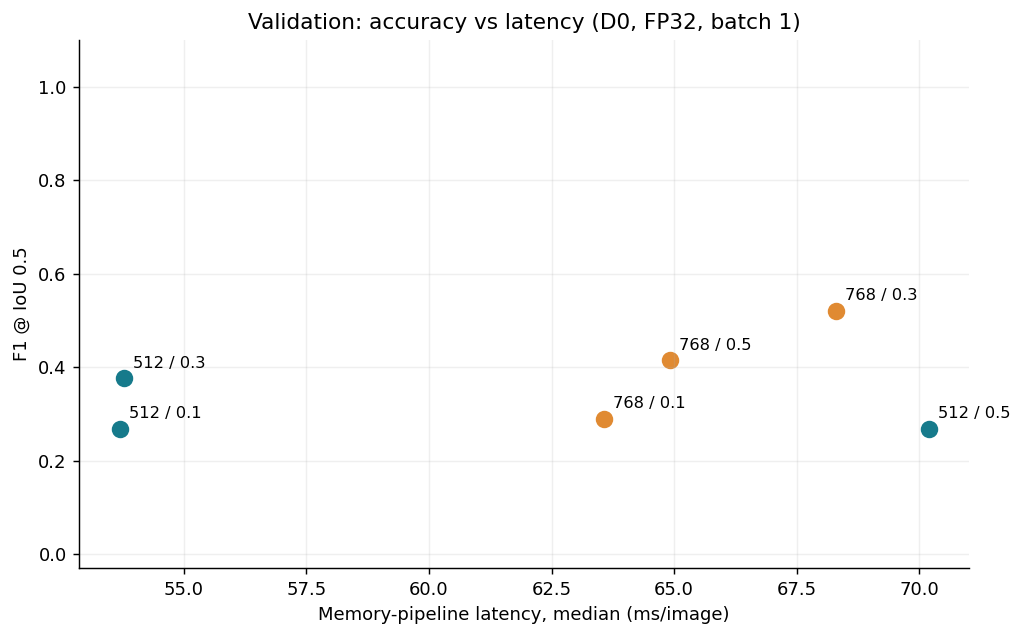

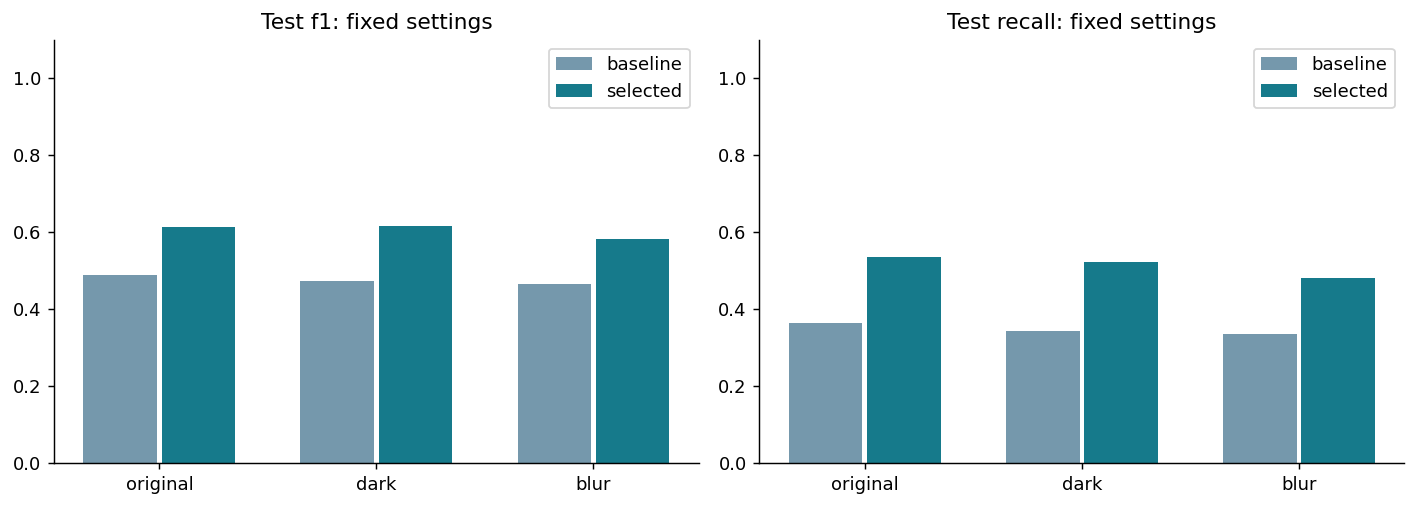

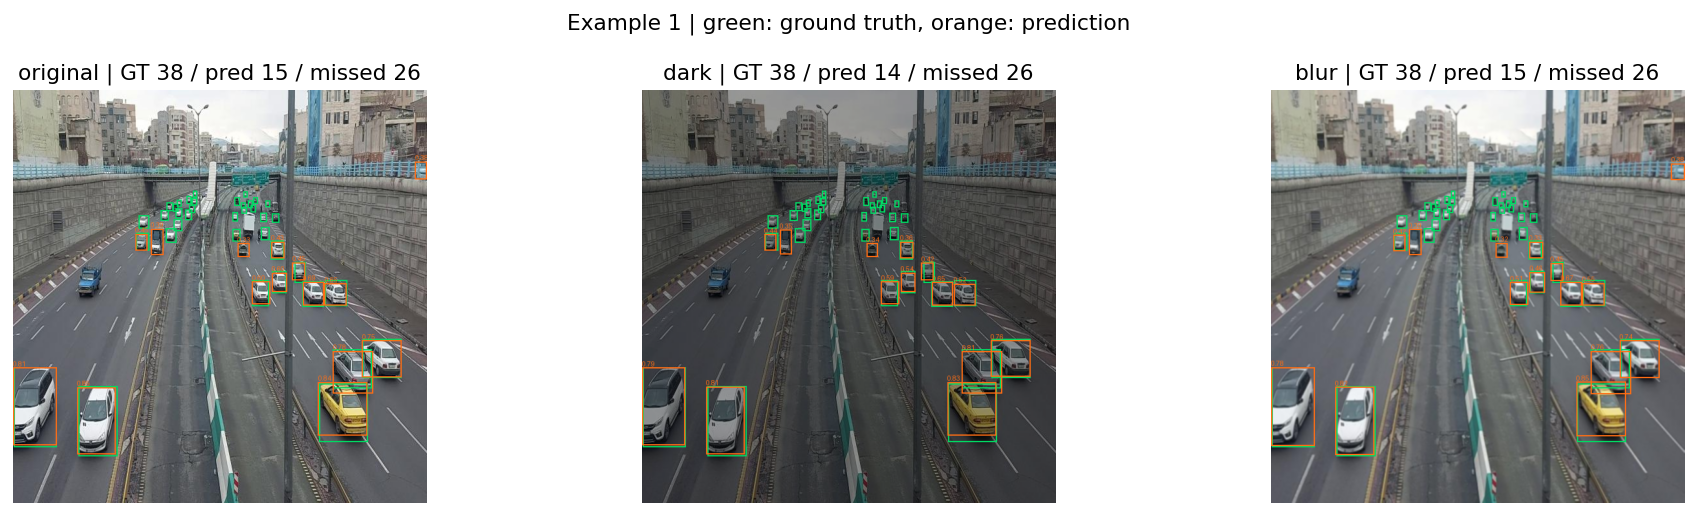

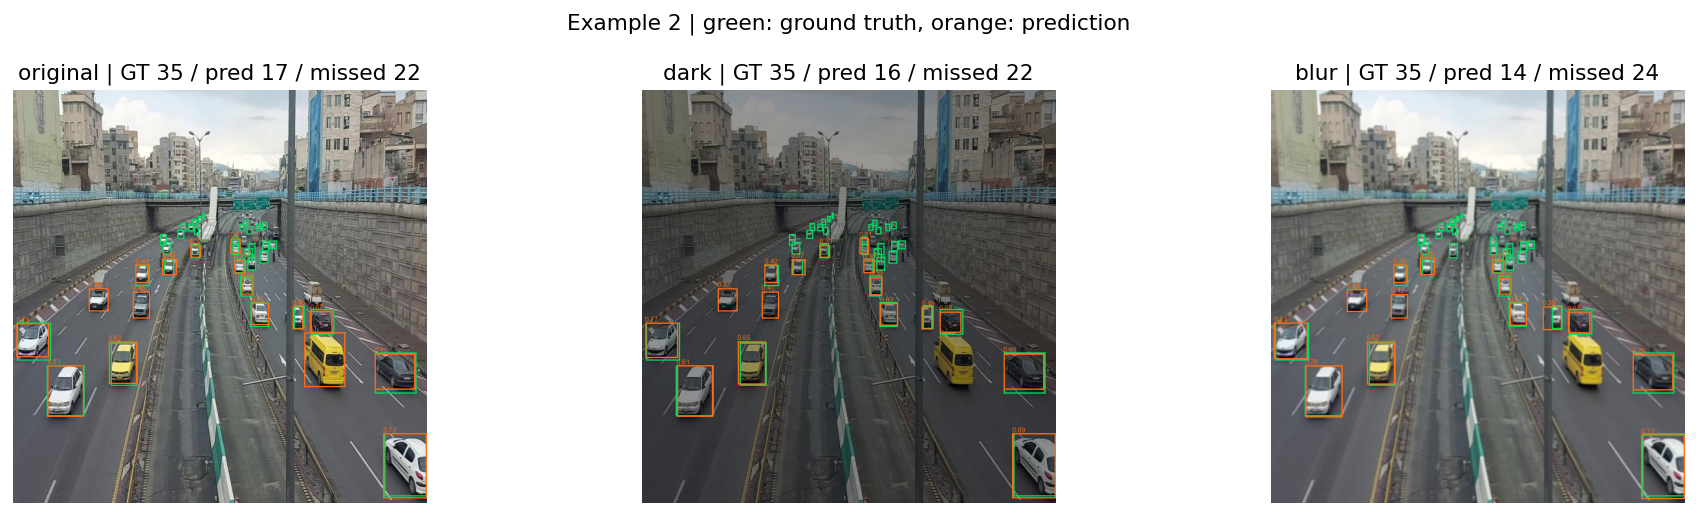

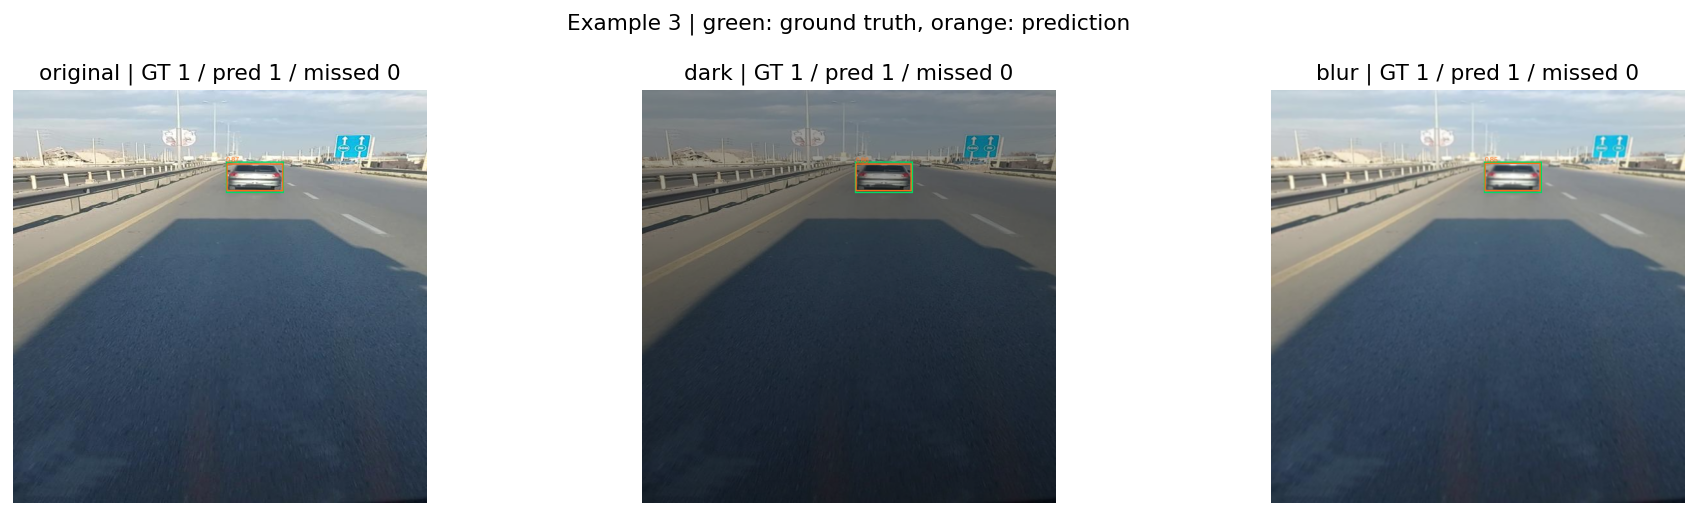

In [9]:
report_path = exp.write_report()
report_text = report_path.read_text(encoding="utf-8")
display(Markdown("\n".join(line for line in report_text.splitlines() if not line.startswith("!["))))
for figure in [exp.output/"figures/validation_tradeoff.png", exp.output/"figures/test_degradation.png"]:
    display(DisplayImage(filename=str(figure)))
for figure in sorted((exp.output/"figures").glob("example_*.png")):
    display(DisplayImage(filename=str(figure)))


### 최종 결과 해석

원본 최종 평가에서 768/0.3은 기본 512/0.3보다 F1이 0.4882에서 0.6126으로 12.45%p, Recall이 0.3654에서 0.5354로 17.00%p 높았다. AP50은 0.4641에서 0.5937로, 작은 차량 Recall은 0.3054에서 0.4930으로 개선됐다. 프레임별 차량 수 MAE도 7.45대에서 6.20대로 줄었다.

대신 중앙 처리 시간은 54.33ms에서 62.91ms로 약 15.8% 늘었다. 차량 누락을 줄이는 목적에서는 이 비용을 감수하고 768/0.3을 선택할 만하다. 다만 선택 설정에서도 정답 706대 중 328대를 놓쳤으므로 실제 출입 관리에 바로 적용하기에는 부족하다. 영상 디코딩을 제외한 속도이므로 실제 CCTV 처리율은 별도 측정해야 한다.

밝기를 0.6배로 낮추면 선택 설정의 F1이 0.6126에서 0.6156으로 소폭 높아졌지만, Recall은 0.5354에서 0.5241로 낮아졌다. TP가 378개에서 370개로 줄면서 FP도 150개에서 126개로 줄어든 결과다. 어두운 영상이 더 좋다는 결론보다, 누락과 오탐을 함께 봐야 한다는 점을 확인했다.

흐림에서는 F1이 0.5820, Recall이 0.4802로 낮아졌고 작은 차량 Recall도 0.4326으로 떨어졌다. 작은 차량의 경계·세부 정보 손실이 원인일 수 있으나, 크기와 가림을 분리한 추가 실험으로 확인해야 한다.

### 실패 사례 분석

| 예시 / 이미지 ID | 원본 결과 | 열화 비교와 해석 |
| --- | --- | --- |
| example_1 / `910a8e9853b53b3e` | 정답 38, TP 12, FP 3, FN 26 | 화면 먼 쪽의 작은 차량이 밀집한 장면이다. 어두움과 흐림에서도 FN 26으로, 원본부터 많은 차량을 놓치는 문제가 크다. |
| example_2 / `6b512c4afc6cb9a8` | 정답 35, TP 13, FP 4, FN 22 | 흐림에서 TP 11, FN 24로 악화됐다. 작은 차량이 많은 장면에서 흐림의 추가 누락을 확인할 수 있다. |
| example_3 / `e69d73377914c3a2` | 정답 1, TP 1, FP 0, FN 0 | 상대적으로 가까운 차량 한 대는 세 조건에서 모두 탐지했다. 이 장면만으로 전체 성능을 설명할 수는 없다. |

실패가 큰 두 장과 오류가 작은 한 장을 함께 살펴봤다. 이 세 장은 전체 데이터의 대표성을 보장하는 무작위 표본이 아니다. 밀집·거리·가림이 동시에 달라지므로 각각의 영향은 아직 분리하지 못했다.

차량 수 MAE는 이미지 안의 승용차 수 오차다. 고유 차량의 누적 통과 대수를 측정한 결과가 아니며, 합성 열화로 실제 야간·우천 성능을 단정할 수 없다.


## 8. 실험 회고와 다음 행동

### Keep

검증 데이터에서 설정을 고른 뒤 최종 평가에 고정한 방법을 유지하고 싶다. 동일 이미지에 원본·어두움·흐림을 적용해 비교하고, F1뿐 아니라 Recall·작은 차량 Recall·처리 시간을 함께 기록한 것도 유지할 점이다. 표와 실패 이미지가 함께 있어 평균 수치 뒤에 남은 누락을 확인하기 쉬웠다.

### Problem

선택 설정의 원본 Recall이 0.5354에 머물렀고 작은 차량 Recall도 0.4930이었다. example_1에서는 38대 중 26대를 놓쳤다. 표본은 검증·평가 각각 60장이고 같은 카메라의 장면일 가능성이 남아 있다. 합성 어두움·흐림만으로 실제 야간·우천 환경을 판단할 수 없고, 속도는 세션을 바꿔 반복 확인하지 못했다.

### Try

다음 실험에서는 이미 고정한 최종 평가 설정을 유지하면서 차량 크기별 누락과 합성 열화 강도별 변화를 분리해 살펴보고 싶다. 새 입력 크기나 다른 모델의 선택이 필요하면 검증 데이터에서 결정하고, 추가로 확보한 별도 장면에서 확인하겠다.

### Action - 무엇을

① 같은 Tesla T4에서 512/0.3과 768/0.3의 속도를 순서를 바꿔 3라운드 측정한다. ② 선택 설정을 고정하고 검증 60장에 밝기 1.0/0.8/0.6/0.4, blur sigma 0/0.5/1.0/1.5(커널 5×5)를 각각 적용한다. ③ 다른 촬영 장소의 공개 차량 이미지 30장 이상과 승용차 박스를 확보해 별도 평가한다.

### Action - 언제

다음 실습 첫 30분에는 속도 반복 측정을, 이어지는 30분에는 열화 강도 비교를 진행한다. 그 다음 실습에서 다른 촬영 장소의 데이터와 주석을 확인한 뒤 고정 설정을 평가한다.

### Action - 완료 기준

① 두 설정 × 3라운드의 원시 처리 시간과 중앙값·p95 표를 저장한다. ② 조건별 F1·Recall·작은 차량 Recall 표와 강도별 그래프를 저장한다. ③ 새 이미지 30장 이상의 출처·분할·주석 점검 기록과 평가 표를 남긴다. 순서별 속도 차이가 크면 속도 순위를 보류하고, 새 장면에서 Recall 하락이 크면 데이터 추가와 미세 조정을 다음 과제로 정한다.

### 실험 범위와 검증

2026-10-04 Tesla T4에서 수행한 실행 기록을 근거로 정리했다. COCO 사전학습 EfficientDet-D0를 사용했고 추가 학습은 하지 않았다. 평가·분할 등 오프라인 테스트 13개가 통과했으며, 실제 AP50은 pycocotools 결과와 일치했다. 별도 동료 피드백 기록과 공개 링크 확인 기록은 없다.

아래 셀은 이 회고를 결과 폴더에도 저장한다. 재실행할 때는 새 측정값과 해석을 반영한다.


In [ ]:
MY_REFLECTION = {
    "주제 선택 이유": "차량과 관련된 컴퓨터비전 문제를 다루고 싶어 차량 탐지를 선택했다. 공장 출입구와 물류 구역의 모니터링을 응용 시나리오로 두고, 2시간 안에 비교할 수 있도록 추가 학습 없이 해상도·임계값·영상 열화의 영향을 살펴봤다.",
    "결과에 대한 해석": "원본 최종 평가에서 768/0.3은 기본 512/0.3보다 F1이 0.4882에서 0.6126으로 12.45%p, Recall이 0.3654에서 0.5354로 17.00%p 높았다. AP50은 0.4641에서 0.5937로, 작은 차량 Recall은 0.3054에서 0.4930으로 개선됐다. 프레임별 차량 수 MAE도 7.45대에서 6.20대로 줄었다.\n\n대신 중앙 처리 시간은 54.33ms에서 62.91ms로 약 15.8% 늘었다. 차량 누락을 줄이는 목적에서는 이 비용을 감수하고 768/0.3을 선택할 만하다. 다만 선택 설정에서도 정답 706대 중 328대를 놓쳤으므로 실제 출입 관리에 바로 적용하기에는 부족하다. 영상 디코딩을 제외한 속도이므로 실제 CCTV 처리율은 별도 측정해야 한다.\n\n밝기를 0.6배로 낮추면 선택 설정의 F1이 0.6126에서 0.6156으로 소폭 높아졌지만, Recall은 0.5354에서 0.5241로 낮아졌다. TP가 378개에서 370개로 줄면서 FP도 150개에서 126개로 줄어든 결과다. 어두운 영상이 더 좋다는 결론보다, 누락과 오탐을 함께 봐야 한다는 점을 확인했다.\n\n흐림에서는 F1이 0.5820, Recall이 0.4802로 낮아졌고 작은 차량 Recall도 0.4326으로 떨어졌다. 작은 차량의 경계·세부 정보 손실이 원인일 수 있으나, 크기와 가림을 분리한 추가 실험으로 확인해야 한다.",
    "Keep": "검증 데이터에서 설정을 고른 뒤 최종 평가에 고정한 방법을 유지하고 싶다. 동일 이미지에 원본·어두움·흐림을 적용해 비교하고, F1뿐 아니라 Recall·작은 차량 Recall·처리 시간을 함께 기록한 것도 유지할 점이다. 표와 실패 이미지가 함께 있어 평균 수치 뒤에 남은 누락을 확인하기 쉬웠다.",
    "Problem": "선택 설정의 원본 Recall이 0.5354에 머물렀고 작은 차량 Recall도 0.4930이었다. example_1에서는 38대 중 26대를 놓쳤다. 표본은 검증·평가 각각 60장이고 같은 카메라의 장면일 가능성이 남아 있다. 합성 어두움·흐림만으로 실제 야간·우천 환경을 판단할 수 없고, 속도는 세션을 바꿔 반복 확인하지 못했다.",
    "Try": "다음 실험에서는 이미 고정한 최종 평가 설정을 유지하면서 차량 크기별 누락과 합성 열화 강도별 변화를 분리해 살펴보고 싶다. 새 입력 크기나 다른 모델의 선택이 필요하면 검증 데이터에서 결정하고, 추가로 확보한 별도 장면에서 확인하겠다.",
    "Action - 무엇을": "① 같은 Tesla T4에서 512/0.3과 768/0.3의 속도를 순서를 바꿔 3라운드 측정한다. ② 선택 설정을 고정하고 검증 60장에 밝기 1.0/0.8/0.6/0.4, blur sigma 0/0.5/1.0/1.5(커널 5×5)를 각각 적용한다. ③ 다른 촬영 장소의 공개 차량 이미지 30장 이상과 승용차 박스를 확보해 별도 평가한다.",
    "Action - 언제": "다음 실습 첫 30분에는 속도 반복 측정을, 이어지는 30분에는 열화 강도 비교를 진행한다. 그 다음 실습에서 다른 촬영 장소의 데이터와 주석을 확인한 뒤 고정 설정을 평가한다.",
    "Action - 완료 기준": "① 두 설정 × 3라운드의 원시 처리 시간과 중앙값·p95 표를 저장한다. ② 조건별 F1·Recall·작은 차량 Recall 표와 강도별 그래프를 저장한다. ③ 새 이미지 30장 이상의 출처·분할·주석 점검 기록과 평가 표를 남긴다. 순서별 속도 차이가 크면 속도 순위를 보류하고, 새 장면에서 Recall 하락이 크면 데이터 추가와 미세 조정을 다음 과제로 정한다.",
    "실험 범위와 검증": "2026-10-04 Tesla T4에서 수행한 실행 기록을 근거로 정리했다. COCO 사전학습 EfficientDet-D0를 사용했고 추가 학습은 하지 않았다. 평가·분할 등 오프라인 테스트 13개가 통과했으며, 실제 AP50은 pycocotools 결과와 일치했다. 별도 동료 피드백 기록과 공개 링크 확인 기록은 없다."
}
missing_reflection = [key for key, value in MY_REFLECTION.items() if not value.strip()]
if missing_reflection:
    raise ValueError(f"회고 항목이 비어 있습니다: {missing_reflection}")
write_json(exp.output/"personal_reflection.json", MY_REFLECTION)
reflection_md = "# 실험 해석과 KPT\n\n" + "\n\n".join(f"## {key}\n\n{value}" for key, value in MY_REFLECTION.items())
(exp.output/"PERSONAL_REFLECTION.md").write_text(reflection_md, encoding="utf-8")
display(Markdown(reflection_md))
print("실험 해석과 KPT 저장 완료")


## 9. 결과 저장과 공개 제출

측정 결과와 회고는 로컬 결과 폴더에 저장했다. 공개 저장소 URL과 비로그인 열람 확인 기록은 아직 등록되어 있지 않다. 아래 셀의 `None`은 기록이 없음을 뜻하며, 공개 확인을 완료했다는 뜻이 아니다.

1. 마지막 셀에서 결과 ZIP을 생성한다.
2. VS Code **Colab → Contents → `/content/efficientdet_vehicle_project/results`**에서 `vehicle_results_`로 시작하는 ZIP을 다운로드한다.
3. 로컬 Project 폴더에 압축 속 `results/`를 합치고, 실행 출력이 있는 노트북도 `Ctrl+S`로 저장한다.
4. README·코드·노트북·결과를 공개 저장소에 올린다.
5. 로그아웃 또는 시크릿 창에서 열리는지 확인한 뒤 실제 주소와 확인 시각을 아래 셀에 기록하고 결과 ZIP을 갱신한다.


In [ ]:
PUBLIC_REPO_URL = None
PUBLIC_README_URL = None
PUBLIC_NOTEBOOK_URL = None
LOGGED_OUT_CHECK_TIME = None

publication_recorded = all([PUBLIC_REPO_URL, PUBLIC_README_URL, PUBLIC_NOTEBOOK_URL, LOGGED_OUT_CHECK_TIME])
checklist = {
    "실제 측정 완료": bool(exp.state.get("measured")),
    "결과 해석·KPT 정리": not missing_reflection,
    "공개 링크 및 비로그인 확인 기록 입력": publication_recorded
}
write_json(exp.output/"submission_checklist.json", {
    "items": checklist, "repository_url": PUBLIC_REPO_URL, "readme_url": PUBLIC_README_URL,
    "notebook_url": PUBLIC_NOTEBOOK_URL, "logged_out_check_time": LOGGED_OUT_CHECK_TIME,
    "publication_status": "공개 확인 기록 있음" if publication_recorded else "공개 링크 미등록 · 비로그인 열람 확인 기록 없음",
    "note": "공개 상태는 열람 확인 기록을 기준으로 하며 코드가 권한을 자동 검증하지는 않는다."
})
archive = exp.export()
display(pd.DataFrame(checklist.items(), columns=["제출 점검", "완료 여부"]))
print("다운로드할 ZIP:", archive)
print("현재 노트북의 실행 출력도 VS Code에서 저장하세요.")


## 참고 자료

- [EfficientDet 논문](https://arxiv.org/abs/1911.09070)
- [사용 모델 구현](https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch)
- [차량 데이터](https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset)
- [COCO 평가 구현](https://github.com/cocodataset/cocoapi)
- [Google Colab VS Code 안내](https://github.com/googlecolab/colab-vscode/wiki/User-Guide)

원본 모델·데이터의 출처와 이용 조건을 유지한다. 데이터와 가중치는 실행할 때 내려받는다.
